In [1]:
import sys
from pathlib import Path

import numpy as np
from qiskit.visualization import array_to_latex
from IPython.display import display, Latex

# Ensure project root is on path so `src` imports work from notebook
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.quantum_states import create_ket0, create_ket1, create_superposition
from src.quantum_operators import (
    create_custom_operator,
    create_identity_matrix,
    combine_operators,
    apply_operator,
    compose_operators,
)

# Format numpy output to always show decimal point
np.set_printoptions(formatter={'float_kind': lambda x: f'{x:.1f}'})

## Quantum State Vectors

Define two basis states: |0⟩ and |1⟩

In [2]:
# Create quantum basis states using our module
ket0 = create_ket0()
ket1 = create_ket1()

print("ket0 (|0⟩):")
print(ket0)
print("\nket1 (|1⟩):")
print(ket1)

ket0 (|0⟩):
[[1.0]
 [0.0]]

ket1 (|1⟩):
[[0.0]
 [1.0]]


## Superposition State

Create an equal superposition: (|0⟩ + |1⟩)/2

In [3]:
superposition = create_superposition(ket0, ket1)
print("Superposition (|0⟩ + |1⟩)/2:")
print(superposition)

Superposition (|0⟩ + |1⟩)/2:
[[0.5]
 [0.5]]


## Quantum Matrices (Operators)

Define quantum gates and operators as matrices

In [4]:
# Create quantum operators using our module
M1 = create_custom_operator()
M2 = create_identity_matrix()
M = combine_operators(M1, M2, weight1=0.5, weight2=0.5)

print("M1 (Custom operator):")
print(M1)
print("\nM2 (Identity):")
print(M2)
print("\nM = (M1 + M2)/2:")
print(M)

M1 (Custom operator):
[[1.0 1.0]
 [0.0 0.0]]

M2 (Identity):
[[1.0 0.0]
 [0.0 1.0]]

M = (M1 + M2)/2:
[[1.0 0.5]
 [0.0 0.5]]


## Matrix-Vector Multiplication

Apply quantum operator M1 to quantum state ket1

In [5]:
result1 = apply_operator(M1, ket1)
print("M1 @ ket1 (Apply M1 to |1⟩):")
print(result1)

M1 @ ket1 (Apply M1 to |1⟩):
[[1.0]
 [0.0]]


## Matrix-Matrix Multiplication

Compose quantum operators

In [6]:
result2 = compose_operators(M1, M2)
print("M1 @ M2 (Compose operators):")
print(result2)

M1 @ M2 (Compose operators):
[[1.0 1.0]
 [0.0 0.0]]


## Self-Composition

Apply operator M twice

In [7]:
result3 = M @ M
print("M @ M (Apply M twice):")
print(result3)

M @ M (Apply M twice):
[[1.0 0.8]
 [0.0 0.2]]


## LaTeX Representation

Display matrices in beautiful mathematical notation

In [8]:
print("M1 @ ket1 in LaTeX:")
display(array_to_latex(M1 @ ket1))

print("\nM1 @ M2 in LaTeX:")
display(array_to_latex(M1 @ M2))

print("\nM @ M in LaTeX:")
display(array_to_latex(M @ M))

M1 @ ket1 in LaTeX:


<IPython.core.display.Latex object>


M1 @ M2 in LaTeX:


<IPython.core.display.Latex object>


M @ M in LaTeX:


<IPython.core.display.Latex object>

True

False

<IPython.core.display.Latex object>

Measured: 1
Post-measurement state:


<IPython.core.display.Latex object>

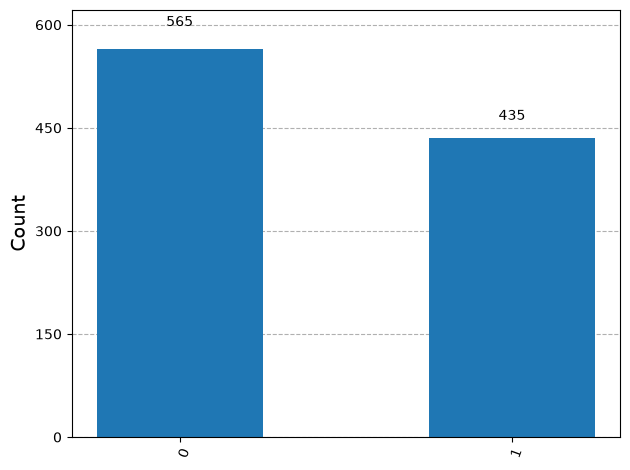

In [9]:
from qiskit.quantum_info import Statevector
from numpy import sqrt

u = Statevector([1 / sqrt(2), 1 / sqrt(2)])
v = Statevector([(1 + 2.0j) / 3, -2 / 3])
w = Statevector([1 / 3, 2 / 3])

display(u.is_valid())
display(w.is_valid())


display(v.draw("latex"))

outcome, state = v.measure()

print(f"Measured: {outcome}\nPost-measurement state:")
display(state.draw("latex"))
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)

In [10]:
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1 / sqrt(2), 1 / sqrt(2)], [1 / sqrt(2), -1 / sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j) / sqrt(2)]])

display(T.draw("latex"))

<IPython.core.display.Latex object>

In [11]:
Apply unitary operation to a state vector using the evolve method

SyntaxError: invalid syntax (1427977988.py, line 1)

In [12]:
v = Statevector([1, 0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw("latex"))

<IPython.core.display.Latex object>

In [13]:
Preview of quantum ciruit

SyntaxError: invalid syntax (595251373.py, line 1)

In [14]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(1)

circuit.h(0)
circuit.t(0)
circuit.h(0)
circuit.s(0)
circuit.y(0)

display(circuit.draw(output="mpl"))

MissingOptionalLibraryError: "The 'pylatexenc' library is required to use 'MatplotlibDrawer'. You can install it with 'pip install pylatexenc'."